# Implementação de uma FCN para Segmentação de Núcleos

Dataset: OralEpitheliumDB_Dataset (imagens de displasia — grupos `healthy` e `severe`).

O objetivo desse notebook é implementar uma rede Fully Convolutional Network (FCN), para segmentação semântica de núcleos em imagens histológicas de epitélio oral (núcleo vs. fundo), relacionando os conceitos do artigo de Long, Shelhamer e Darrell (2015) com uma aplicação prática de segmentação biomédica.

Serão realizados dois experimentos:
1. Experimento 1 — FCN treinada sem aumento de dados;
2. Experimento 2 — FCN treinada com aumento de dados geométrico (rotação, espelhamentos horizontal/vertical, transposição).

Ao final, os dois experimentos são comparados através das métricas DICE, acurácia de pixels e IoU.


## Configuração

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import glob
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from torchvision.models.segmentation.fcn import FCNHead

from sklearn.model_selection import train_test_split

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Estilo dos gráficos
plt.rcParams['figure.figsize'] = (12, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")


Usando device: cuda


In [3]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Dados_Exploratorios/datasets")
IMAGES_DIR = BASE_DIR / "Original_ROI_images"
MASKS_DIR = BASE_DIR / "Gold_Standard_Semantic_Segmentation"

GROUPS = ["healthy", "severe"]

def list_images(group: str):
    folder = IMAGES_DIR / group
    return sorted([str(p) for p in folder.glob("*.tif")])

def get_mask_path(image_path: str, group: str):
    # As máscaras Gold Standard usam o mesmo nome da imagem original,
    # trocando a extensão de .tif (imagem) para .png (máscara).
    filename = os.path.basename(image_path)
    name_no_ext = os.path.splitext(filename)[0]
    return MASKS_DIR / group / f"{name_no_ext}.png"

image_paths = []
for group in GROUPS:
    paths = list_images(group)
    print(f"Grupo '{group}': {len(paths)} imagens encontradas")
    image_paths.extend([(p, group) for p in paths])

print(f"\nTotal de imagens (healthy + severe): {len(image_paths)}")


Grupo 'healthy': 114 imagens encontradas
Grupo 'severe': 114 imagens encontradas

Total de imagens (healthy + severe): 228


## Visualização

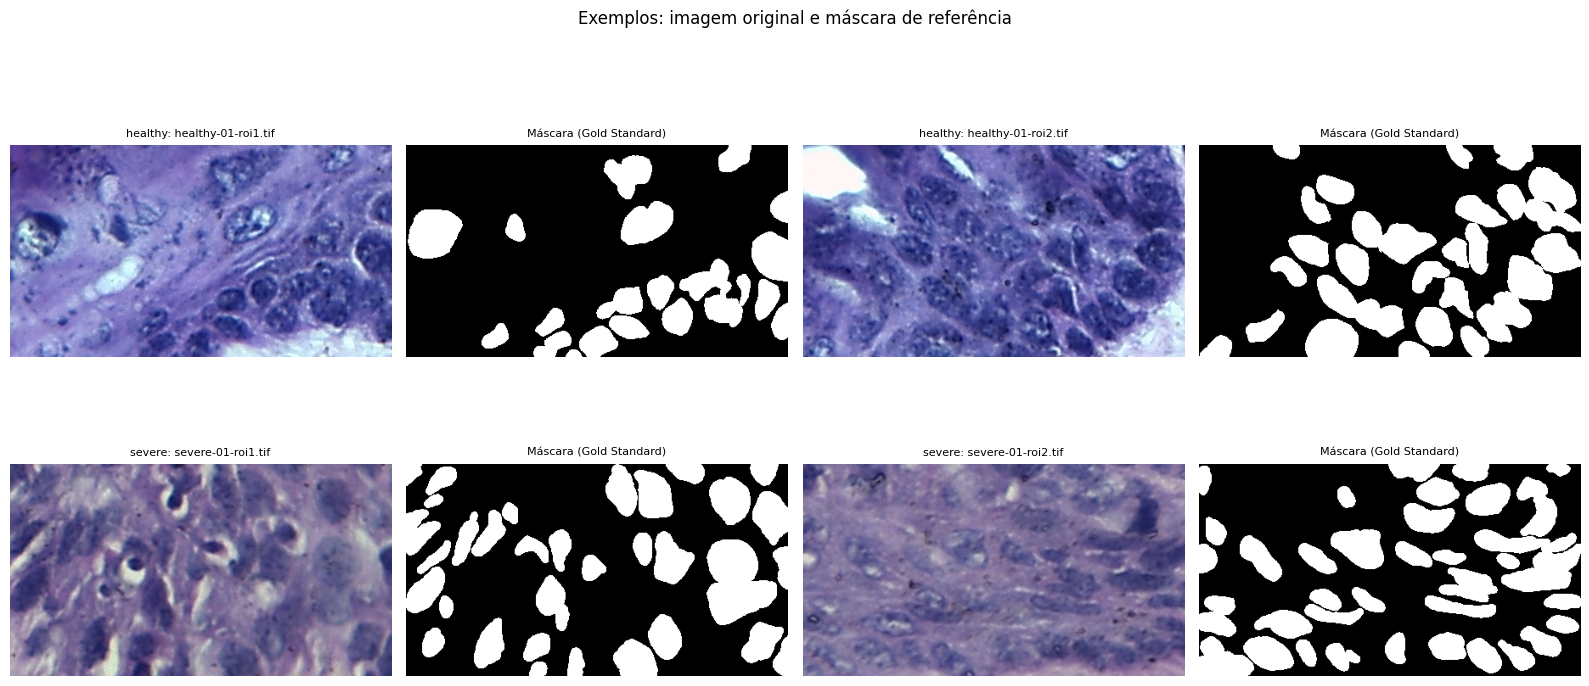

In [4]:
def show_pair(image_path, group, ax_img, ax_mask):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(get_mask_path(image_path, group)), cv2.IMREAD_GRAYSCALE)

    ax_img.imshow(img_rgb)
    ax_img.set_title(f"{group}: {os.path.basename(image_path)}", fontsize=8)
    ax_img.axis("off")

    ax_mask.imshow(mask, cmap="gray")
    ax_mask.set_title("Máscara (Gold Standard)", fontsize=8)
    ax_mask.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, group in enumerate(GROUPS):
    group_paths = [p for p, g in image_paths if g == group][:2]
    for j, p in enumerate(group_paths):
        show_pair(p, group, axes[i, j*2], axes[i, j*2 + 1])
fig.suptitle("Exemplos: imagem original e máscara de referência")
plt.tight_layout()
plt.show()


## Divisão em treino / validação / teste

A divisão é estratificada pelo grupo (`healthy` / `severe`) para manter a proporção entre os dois grupos em cada conjunto.

In [5]:
groups_all = [g for _, g in image_paths]

train_data, temp_data = train_test_split(
    image_paths, test_size=0.30, random_state=SEED, stratify=groups_all
)
temp_groups = [g for _, g in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.50, random_state=SEED, stratify=temp_groups
)

print(f"Treino: {len(train_data)} imagens")
print(f"Validação: {len(val_data)} imagens")
print(f"Teste: {len(test_data)} imagens")


Treino: 159 imagens
Validação: 34 imagens
Teste: 35 imagens


## Dataset PyTorch

Classe `Dataset` que carrega o par (imagem, máscara), redimensiona ambos para um tamanho fixo, binariza a máscara (0 = fundo, 1 = núcleo) e normaliza a imagem com as estatísticas do ImageNet, necessárias porque o backbone da FCN é pré-treinado.

Quando `augment=True`, aplica as mesmas transformações geométricas na imagem e na máscara.

In [6]:
IMG_SIZE = 256  # redimensionamento usado para padronizar a entrada da rede

class OralEpitheliumDataset(Dataset):
    """Dataset para segmentação binária (núcleo vs. fundo) do OralEpitheliumDB."""

    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, data, img_size=IMG_SIZE, augment=False):
        self.data = data  # image_path, group
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def _load_pair(self, image_path, group):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(get_mask_path(image_path, group)), cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        mask = (mask > 0).astype(np.uint8)  # 0 = fundo, 1 = núcleo
        return img, mask

    def _geometric_augment(self, img, mask):
        if random.random() < 0.5:  # espelhamento horizontal
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        if random.random() < 0.5:  # espelhamento vertical
            img = np.flipud(img).copy()
            mask = np.flipud(mask).copy()
        if random.random() < 0.5:  # transposição
            img = np.transpose(img, (1, 0, 2)).copy()
            mask = np.transpose(mask, (1, 0)).copy()
        if random.random() < 0.5:  # rotação em múltiplos de 90 graus
            k = random.choice([1, 2, 3])
            img = np.rot90(img, k).copy()
            mask = np.rot90(mask, k).copy()
        return img, mask

    def __getitem__(self, idx):
        image_path, group = self.data[idx]
        img, mask = self._load_pair(image_path, group)

        if self.augment:
            img, mask = self._geometric_augment(img, mask)

        img = img.astype(np.float32) / 255.0
        img = (img - self.MEAN) / self.STD
        img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask_tensor = torch.from_numpy(mask).long()

        return img_tensor, mask_tensor

# Teste rápido
ds_demo = OralEpitheliumDataset(train_data[:1])
img_t, mask_t = ds_demo[0]
print(f"Imagem: {img_t.shape} | Máscara: {mask_t.shape} | Classes na máscara: {mask_t.unique().tolist()}")


Imagem: torch.Size([3, 256, 256]) | Máscara: torch.Size([256, 256]) | Classes na máscara: [0, 1]


## Configuração da rede FCN

Utilizamos a `fcn_resnet50` do torchvision com pesos pré-treinados. Como nossa tarefa é binária (fundo vs. núcleo), a camada final (`classifier`) e o classificador auxiliar (`aux_classifier`) são substituídos por novas `FCNHead` com 2 classes de saída, mantendo o backbone ResNet-50 pré-treinado.

In [7]:
NUM_CLASSES = 2  # 0: fundo, 1: núcleo

def build_fcn_model(num_classes=NUM_CLASSES):
    weights = FCN_ResNet50_Weights.DEFAULT
    model = fcn_resnet50(weights=weights)

    # Ajusta a cabeça de classificação para o número de classes da nossa tarefa,
    # mantendo o backbone (ResNet-50) com os pesos pré-treinados.
    model.classifier = FCNHead(2048, num_classes)
    model.aux_classifier = FCNHead(1024, num_classes)

    return model.to(device)

# Teste rápido de forward
_model_demo = build_fcn_model()
with torch.no_grad():
    _out_demo = _model_demo(img_t.unsqueeze(0).to(device))
print("Chaves de saída da FCN:", list(_out_demo.keys()))
print("Formato de outputs['out']:", _out_demo["out"].shape)
del _model_demo, _out_demo


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:01<00:00, 140MB/s]


Chaves de saída da FCN: ['out', 'aux']
Formato de outputs['out']: torch.Size([1, 2, 256, 256])


## Métricas de avaliação

- **DICE**: mede a sobreposição entre a máscara prevista e a máscara real (classe núcleo).
- **Acurácia de pixels**: proporção de pixels classificados corretamente (todas as classes).
- **IoU**: razão entre interseção e união da máscara prevista com a real (classe núcleo).

As métricas são calculadas imagem a imagem no conjunto de teste, e depois resumidas (média e desvio padrão).

In [8]:
def pair_metrics(pred, true):
    """Calcula DICE, IoU (classe núcleo) e acurácia de pixels para um único par (pred, true)."""
    pred_fg = (pred == 1)
    true_fg = (true == 1)

    intersection = np.logical_and(pred_fg, true_fg).sum()
    union = np.logical_or(pred_fg, true_fg).sum()
    total = pred_fg.sum() + true_fg.sum()

    dice = 1.0 if total == 0 else (2.0 * intersection) / total
    iou = 1.0 if union == 0 else intersection / union
    pixel_acc = (pred == true).sum() / true.size

    return dice, iou, pixel_acc


## Funções de treinamento e avaliação

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)["out"]
        loss = criterion(outputs, masks)
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_metrics(model, loader, filenames):
    """Avalia o modelo em um DataLoader (batch_size=1) e retorna um DataFrame
    com DICE, IoU e acurácia de pixels calculados imagem a imagem."""
    model.eval()
    rows = []
    idx = 0
    for imgs, masks in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)["out"]
        preds = outputs.argmax(dim=1).cpu().numpy()
        trues = masks.numpy()

        for b in range(imgs.size(0)):
            dice, iou, pixel_acc = pair_metrics(preds[b], trues[b])
            rows.append({
                "filename": filenames[idx],
                "dice": dice,
                "iou": iou,
                "pixel_acc": pixel_acc,
            })
            idx += 1

    return pd.DataFrame(rows)


def run_experiment(train_data, val_data, test_data, augment_train,
                    epochs=15, batch_size=8, lr=1e-4, exp_name="exp"):
    train_ds = OralEpitheliumDataset(train_data, augment=augment_train)
    val_ds = OralEpitheliumDataset(val_data, augment=False)
    test_ds = OralEpitheliumDataset(test_data, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

    model = build_fcn_model(num_classes=NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate_loss(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{exp_name}] Época {epoch:02d}/{epochs} — loss treino: {train_loss:.4f} | loss validação: {val_loss:.4f}")

    test_filenames = [os.path.basename(p) for p, g in test_data]
    df_metrics = evaluate_metrics(model, test_loader, test_filenames)

    config = {
        "Função de perda": "CrossEntropyLoss",
        "Otimizador": "Adam",
        "Taxa de aprendizado": lr,
        "Número de épocas": epochs,
        "Tamanho do batch": batch_size,
        "Aumento de dados": "Sim (geométrico)" if augment_train else "Não",
    }

    return model, history, df_metrics, config


## Experimento 1: FCN sem aumento de dados

Treinamento utilizando apenas as imagens originais do dataset.

In [10]:
model_exp1, history_exp1, df_metrics_exp1, config_exp1 = run_experiment(
    train_data, val_data, test_data,
    augment_train=False,
    epochs=15, batch_size=8, lr=1e-4,
    exp_name="Exp. 1 (sem aumento)"
)

pd.DataFrame([config_exp1])


[Exp. 1 (sem aumento)] Época 01/15 — loss treino: 0.5429 | loss validação: 0.4418
[Exp. 1 (sem aumento)] Época 02/15 — loss treino: 0.3678 | loss validação: 0.3425
[Exp. 1 (sem aumento)] Época 03/15 — loss treino: 0.2995 | loss validação: 0.3288
[Exp. 1 (sem aumento)] Época 04/15 — loss treino: 0.2495 | loss validação: 0.3266
[Exp. 1 (sem aumento)] Época 05/15 — loss treino: 0.2141 | loss validação: 0.3292
[Exp. 1 (sem aumento)] Época 06/15 — loss treino: 0.1850 | loss validação: 0.3395
[Exp. 1 (sem aumento)] Época 07/15 — loss treino: 0.1650 | loss validação: 0.3440
[Exp. 1 (sem aumento)] Época 08/15 — loss treino: 0.1518 | loss validação: 0.3471
[Exp. 1 (sem aumento)] Época 09/15 — loss treino: 0.1372 | loss validação: 0.3660
[Exp. 1 (sem aumento)] Época 10/15 — loss treino: 0.1263 | loss validação: 0.3676
[Exp. 1 (sem aumento)] Época 11/15 — loss treino: 0.1189 | loss validação: 0.3782
[Exp. 1 (sem aumento)] Época 12/15 — loss treino: 0.1110 | loss validação: 0.3834
[Exp. 1 (sem aum

,Função de perda,Otimizador,Taxa de aprendizado,Número de épocas,Tamanho do batch,Aumento de dados
0,CrossEntropyLoss,Adam,0.0001,15,8,Não


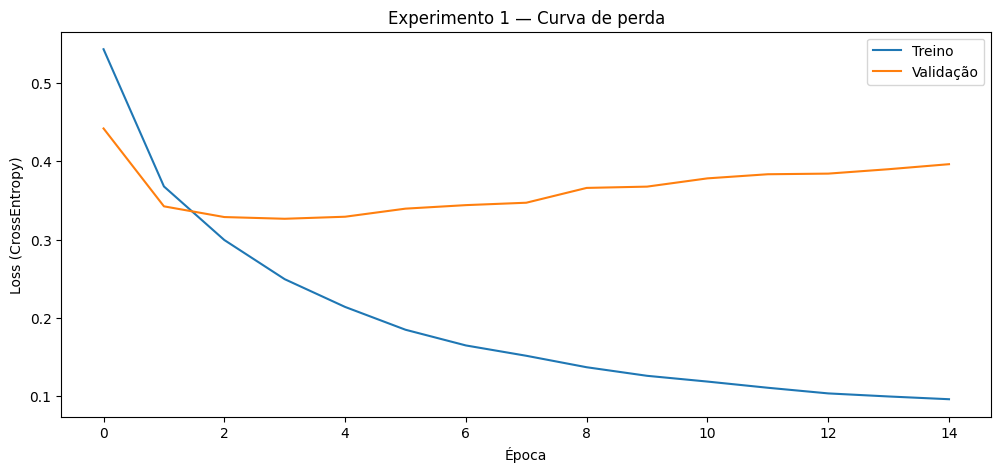

Métricas no conjunto de teste — Experimento 1:


,dice,iou,pixel_acc
mean,0.754880,0.610519,0.863602
std,0.065626,0.083121,0.046469


In [11]:
plt.plot(history_exp1["train_loss"], label="Treino")
plt.plot(history_exp1["val_loss"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Loss (CrossEntropy)")
plt.title("Experimento 1 — Curva de perda")
plt.legend()
plt.show()

print("Métricas no conjunto de teste — Experimento 1:")
df_metrics_exp1[["dice", "iou", "pixel_acc"]].agg(["mean", "std"])


## Experimento 2: FCN com aumento de dados geométrico

Mesma configuração do Experimento 1, mas agora aplicando aumento de dados geométrico (espelhamentos, transposição e rotação em múltiplos de 90°) apenas no conjunto de treino. As mesmas transformações são aplicadas à imagem e à máscara correspondente, feito dentro do `OralEpitheliumDataset`.

In [12]:
model_exp2, history_exp2, df_metrics_exp2, config_exp2 = run_experiment(
    train_data, val_data, test_data,
    augment_train=True,
    epochs=15, batch_size=8, lr=1e-4,
    exp_name="Exp. 2 (com aumento geométrico)"
)

pd.DataFrame([config_exp2])


[Exp. 2 (com aumento geométrico)] Época 01/15 — loss treino: 0.5163 | loss validação: 0.5511
[Exp. 2 (com aumento geométrico)] Época 02/15 — loss treino: 0.3893 | loss validação: 0.3564
[Exp. 2 (com aumento geométrico)] Época 03/15 — loss treino: 0.3540 | loss validação: 0.3275
[Exp. 2 (com aumento geométrico)] Época 04/15 — loss treino: 0.3262 | loss validação: 0.3088
[Exp. 2 (com aumento geométrico)] Época 05/15 — loss treino: 0.3086 | loss validação: 0.2988
[Exp. 2 (com aumento geométrico)] Época 06/15 — loss treino: 0.2948 | loss validação: 0.2899
[Exp. 2 (com aumento geométrico)] Época 07/15 — loss treino: 0.2841 | loss validação: 0.2878
[Exp. 2 (com aumento geométrico)] Época 08/15 — loss treino: 0.2796 | loss validação: 0.3068
[Exp. 2 (com aumento geométrico)] Época 09/15 — loss treino: 0.2685 | loss validação: 0.2834
[Exp. 2 (com aumento geométrico)] Época 10/15 — loss treino: 0.2624 | loss validação: 0.2736
[Exp. 2 (com aumento geométrico)] Época 11/15 — loss treino: 0.2573 | 

,Função de perda,Otimizador,Taxa de aprendizado,Número de épocas,Tamanho do batch,Aumento de dados
0,CrossEntropyLoss,Adam,0.0001,15,8,Sim (geométrico)


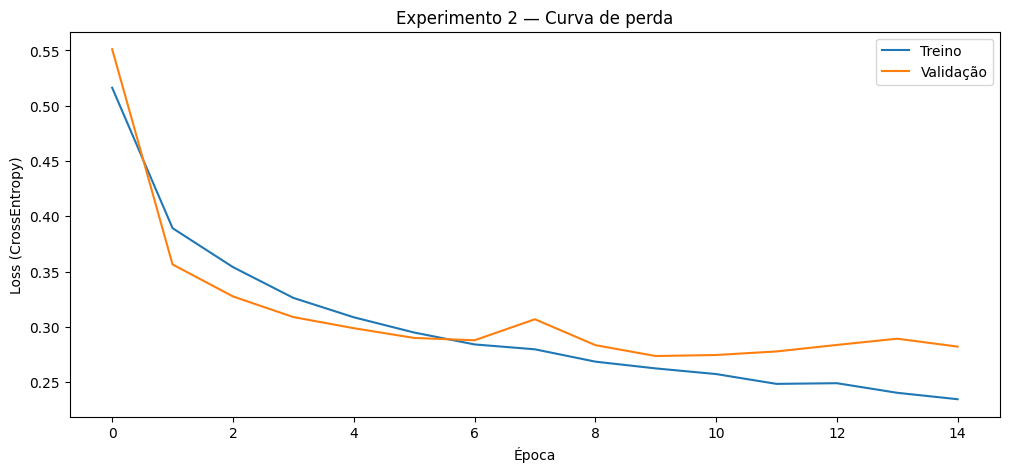

Métricas no conjunto de teste — Experimento 2:


,dice,iou,pixel_acc
mean,0.758919,0.616439,0.870813
std,0.070436,0.089848,0.051029


In [13]:
plt.plot(history_exp2["train_loss"], label="Treino")
plt.plot(history_exp2["val_loss"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Loss (CrossEntropy)")
plt.title("Experimento 2 — Curva de perda")
plt.legend()
plt.show()

print("Métricas no conjunto de teste — Experimento 2:")
df_metrics_exp2[["dice", "iou", "pixel_acc"]].agg(["mean", "std"])


## Comparação dos resultados

In [14]:
def summarize(df_metrics, config, label):
    return {
        "Experimento": label,
        "Aumento de dados": config["Aumento de dados"],
        "DICE": df_metrics["dice"].mean(),
        "Acurácia de pixels": df_metrics["pixel_acc"].mean(),
        "IoU": df_metrics["iou"].mean(),
        "Observações": "",
    }

summary_rows = [
    summarize(df_metrics_exp1, config_exp1, "FCN sem aumento de dados"),
    summarize(df_metrics_exp2, config_exp2, "FCN com aumento geométrico"),
]
df_summary = pd.DataFrame(summary_rows)
df_summary


,Experimento,Aumento de dados,DICE,Acurácia de pixels,IoU,Observações
0,FCN sem aumento de dados,Não,0.754880,0.863602,0.610519,
1,FCN com aumento geométrico,Sim (geométrico),0.758919,0.870813,0.616439,


## Exemplos visuais das segmentações

--- Experimento 1 (sem aumento) ---


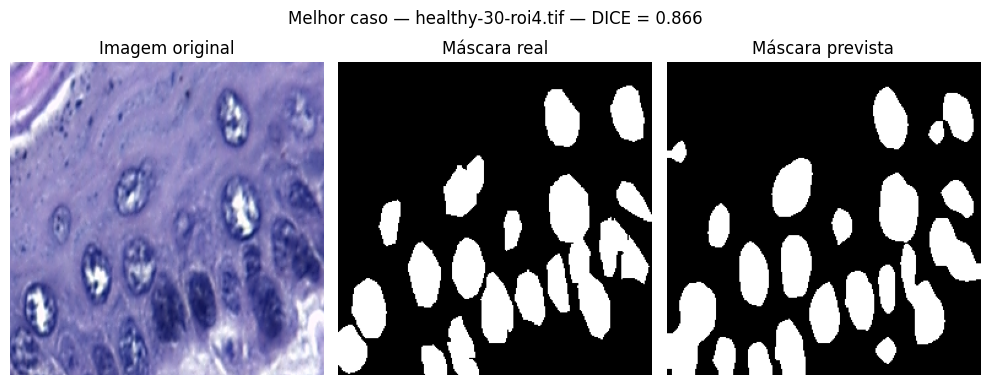

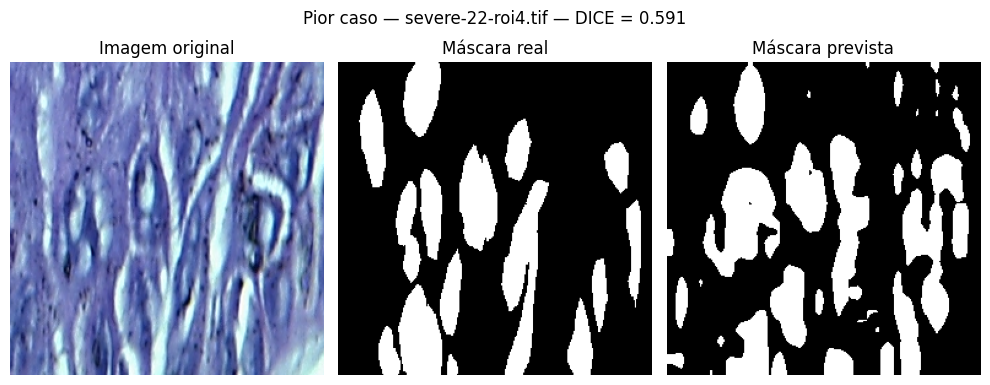

--- Experimento 2 (com aumento geométrico) ---


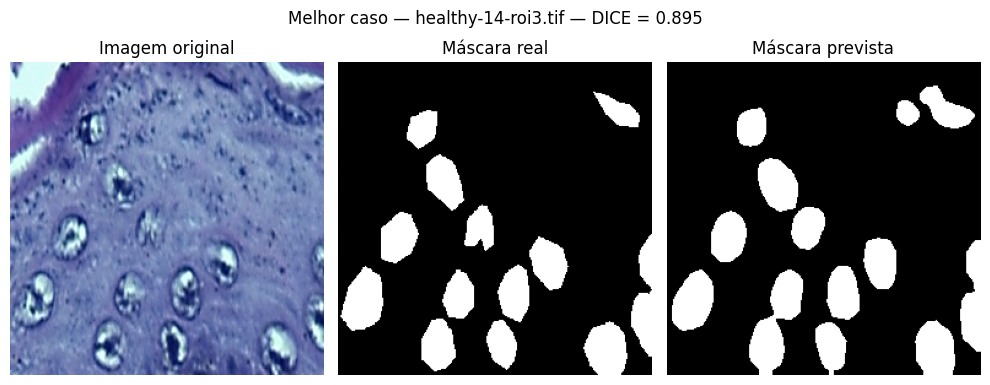

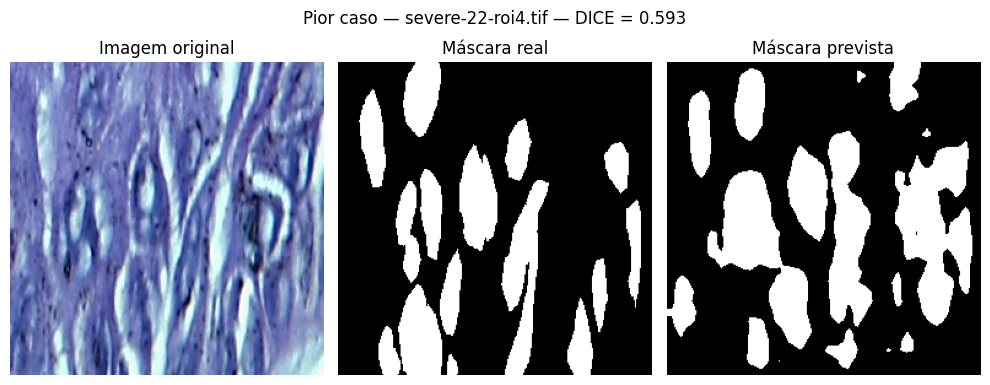

In [15]:
@torch.no_grad()
def predict_mask(model, image_path, group, img_size=IMG_SIZE):
    ds = OralEpitheliumDataset([(image_path, group)], img_size=img_size, augment=False)
    img_tensor, mask_tensor = ds[0]
    model.eval()
    output = model(img_tensor.unsqueeze(0).to(device))["out"]
    pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
    return pred, mask_tensor.numpy()


def show_prediction(model, df_metrics, test_data, pick="max", title=""):
    idx = df_metrics["dice"].idxmax() if pick == "max" else df_metrics["dice"].idxmin()
    filename = df_metrics.loc[idx, "filename"]
    image_path, group = next((p, g) for p, g in test_data if os.path.basename(p) == filename)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    pred, true_mask = predict_mask(model, image_path, group)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(img_rgb); axes[0].set_title("Imagem original"); axes[0].axis("off")
    axes[1].imshow(true_mask, cmap="gray"); axes[1].set_title("Máscara real"); axes[1].axis("off")
    axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Máscara prevista"); axes[2].axis("off")
    dice_val = df_metrics.loc[idx, "dice"]
    fig.suptitle(f"{title} — {filename} — DICE = {dice_val:.3f}")
    plt.tight_layout()
    plt.show()

print("--- Experimento 1 (sem aumento) ---")
show_prediction(model_exp1, df_metrics_exp1, test_data, pick="max", title="Melhor caso")
show_prediction(model_exp1, df_metrics_exp1, test_data, pick="min", title="Pior caso")

print("--- Experimento 2 (com aumento geométrico) ---")
show_prediction(model_exp2, df_metrics_exp2, test_data, pick="max", title="Melhor caso")
show_prediction(model_exp2, df_metrics_exp2, test_data, pick="min", title="Pior caso")


## Análise dos resultados

1. A FCN conseguiu segmentar corretamente os núcleos?

Em parte, sim. O DICE ficou entre 0,75 e 0,76, o que mostra que a rede conseguiu identificar boa parte da região dos núcleos. Nos melhores exemplos, a máscara prevista ficou bem parecida com a máscara real. Porém, o IoU de aproximadamente 0,61 indica que ainda existem erros, principalmente nos contornos e nos detalhes menores. Em alguns casos, a segmentação ficou mais "suavizada" e não acompanhou exatamente o formato dos núcleos. Então, o modelo consegue fazer uma boa segmentação de forma geral, mas ainda perde precisão em regiões mais detalhadas.

2. O aumento de dados geométrico melhorou os resultados?

Sim, mas a melhora nas métricas finais foi pequena. O DICE aumentou cerca de 0,004, o IoU cerca de 0,006 e a acurácia aproximadamente 0,007. Apesar disso, o principal benefício apareceu durante o treinamento. Sem aumento de dados, a perda de treino continuou diminuindo enquanto a de validação começou a aumentar, mostrando que o modelo estava sofrendo overfitting. Já com o aumento de dados, as curvas ficaram mais equilibradas e a perda de validação permaneceu estável. Isso indica que o modelo conseguiu generalizar melhor, mesmo que o ganho nas métricas finais tenha sido pequeno.

3. Qual métrica apresentou maior diferença entre os dois experimentos?

A maior diferença foi na acurácia de pixels, que aumentou cerca de 0,007. Depois vieram o IoU, com aproximadamente 0,006, e o DICE, com cerca de 0,004. Mesmo assim, todas essas diferenças foram pequenas. O que mais chamou atenção foi a redução do overfitting observada nas curvas de treinamento, e não exatamente os valores finais das métricas.

4. A acurácia de pixels foi suficiente para avaliar corretamente o desempenho do modelo?

Não. Apesar da acurácia ter ficado em torno de 0,86–0,87, esse valor pode dar uma impressão melhor do que o desempenho real. Como a maior parte da imagem é formada pelo fundo, o modelo acerta muitos pixels apenas classificando corretamente essa região. Já o IoU, que ficou perto de 0,61, mostra melhor o desempenho na segmentação dos núcleos, que é a classe realmente importante.

5. Por que o IoU pode ser mais informativo que a acurácia quando o fundo domina?

Porque a acurácia considera todos os pixels da imagem, incluindo o fundo, que representa a maior parte dela. Assim, um modelo pode ter uma acurácia alta mesmo errando bastante os núcleos. O IoU avalia apenas a sobreposição entre a máscara prevista e a máscara real da classe de interesse, penalizando tanto falsos positivos quanto falsos negativos. Por isso, ele representa melhor a qualidade da segmentação.

6. O modelo teve mais dificuldade com núcleos pequenos, agrupados ou nas bordas?

Sim. O modelo teve mais dificuldade principalmente com núcleos pequenos e muito próximos uns dos outros. Nesses casos, a máscara prevista ficou mais contínua e arredondada, enquanto a máscara real mostrava vários núcleos separados. Isso acontece porque a arquitetura utilizada não possui skip connections, então ela perde parte das informações de detalhes durante o processo de redução da imagem e acaba gerando segmentações mais suaves.

7. Quais erros foram mais frequentes: falsos positivos ou falsos negativos?

Os falsos negativos apareceram com mais frequência. Em vários casos, núcleos pequenos presentes na máscara real simplesmente não foram detectados pelo modelo. Também aconteceu de núcleos muito próximos serem unidos em uma única região, fazendo com que alguns detalhes fossem perdidos. Esse tipo de erro contribuiu bastante para a redução do IoU.

8. Relação com as ideias do artigo da FCN (Long, Shelhamer & Darrell, 2015)

Os resultados obtidos estão de acordo com o que é discutido no artigo. A FCN conseguiu aproveitar uma rede pré-treinada para realizar segmentação em imagens histológicas, mostrando um desempenho satisfatório, com DICE próximo de 0,75. Por outro lado, também apareceu uma limitação já citada pelos autores: utilizar apenas as características mais profundas da rede faz com que detalhes finos sejam perdidos. Isso explica por que algumas máscaras ficaram borradas e alguns núcleos próximos foram agrupados. É justamente por esse motivo que o artigo propõe versões da FCN com skip connections, que combinam informações de diferentes níveis da rede para melhorar a qualidade da segmentação.